# Tutorial: Comparing Two Networks with GUDHI

This notebook shows how to compare two networks using tools from **topological data analysis (TDA)** and **GUDHI**.

We will compare two synthetic networks:

1. A **community network** with two dense groups and sparse connections between them
2. A **random network** with roughly similar size but less community structure

The tutorial uses a graph-based filtration. We turn each weighted network into a filtered simplicial complex using a **clique complex** construction:

- Vertices are nodes.
- Edges appear according to a filtration value derived from edge weights.
- Triangles appear when all three pairwise edges are present.

Then we compute persistent homology and compare the networks using persistence summaries and bottleneck distances.

## 1. Install dependencies

Run the following cell if you do not already have the required packages installed.

In [1]:
# Uncomment and run if needed:
# %pip install gudhi numpy matplotlib networkx

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 2. Import libraries

In [2]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import gudhi as gd

np.random.seed(42)

## 3. Why compare networks with persistent homology?

Many graph statistics compare networks at one fixed scale: number of edges, clustering coefficient, modularity, average path length, and so on.

Persistent homology gives a complementary view. It studies how topological features appear and disappear as we sweep through many edge-weight thresholds.

In a network setting:

- **H0** tracks connected components merging.
- **H1** tracks loop-like structures in the clique complex.

A network with strong community structure may have different H0 behavior than a random network. A network with many cyclic patterns may show different H1 behavior.

## 4. Create two weighted networks

We will create two graphs with the same number of nodes.

The first graph has two communities. Edges inside communities tend to be stronger than edges between communities.

The second graph is a random weighted graph.

In [3]:
n_nodes = 24
community_size = n_nodes // 2


def make_weighted_community_graph(n_nodes=24, p_in=0.75, p_out=0.12, seed=42):
    rng = np.random.default_rng(seed)
    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))

    for i, j in itertools.combinations(range(n_nodes), 2):
        same_community = (i < n_nodes // 2 and j < n_nodes // 2) or (i >= n_nodes // 2 and j >= n_nodes // 2)
        p = p_in if same_community else p_out

        if rng.random() < p:
            if same_community:
                weight = rng.uniform(0.65, 1.0)
            else:
                weight = rng.uniform(0.15, 0.45)
            G.add_edge(i, j, weight=weight)

    return G


def make_weighted_random_graph(n_nodes=24, p=0.38, seed=7):
    rng = np.random.default_rng(seed)
    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))

    for i, j in itertools.combinations(range(n_nodes), 2):
        if rng.random() < p:
            weight = rng.uniform(0.15, 1.0)
            G.add_edge(i, j, weight=weight)

    return G


G_community = make_weighted_community_graph(n_nodes=n_nodes)
G_random = make_weighted_random_graph(n_nodes=n_nodes)

## 5. Visualize the networks

Edge widths are proportional to edge weights.

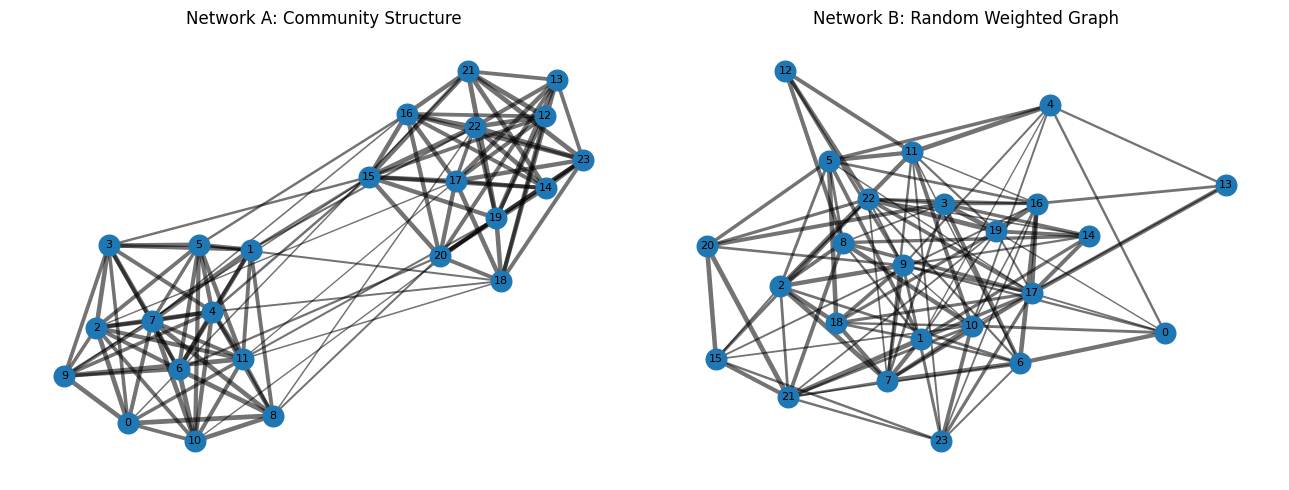

In [4]:
def plot_weighted_graph(G, ax, title, pos=None):
    if pos is None:
        pos = nx.spring_layout(G, seed=42, weight="weight")

    weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
    widths = 0.5 + 3.0 * weights

    nx.draw_networkx_nodes(G, pos, node_size=220, ax=ax)
    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.55, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

    ax.set_title(title)
    ax.axis("off")

    return pos


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pos_community = plot_weighted_graph(G_community, axes[0], "Network A: Community Structure")
pos_random = plot_weighted_graph(G_random, axes[1], "Network B: Random Weighted Graph")

plt.tight_layout()
plt.show()

## 6. Define a graph filtration

GUDHI's `SimplexTree` can represent a filtered simplicial complex. We will build the complex directly from the network.

For each edge with weight $w$, define its filtration value as:

$$f(e) = 1 - w$$

This means stronger edges appear earlier in the filtration.

For a triangle, we assign the maximum filtration value among its three edges. This ensures the triangle appears only after all of its boundary edges have appeared.

In [6]:
def graph_to_clique_simplex_tree(G, max_dimension=2):
    """
    Convert a weighted graph to a filtered clique complex in a GUDHI SimplexTree.

    Vertices have filtration value 0.
    Edges have filtration value 1 - weight.
    Triangles have filtration value equal to the maximum filtration value of their edges.

    Parameters
    ----------
    G : networkx.Graph
        Weighted graph. Each edge must have a 'weight' attribute in [0, 1].
    max_dimension : int
        Maximum dimension of simplices to include. This tutorial uses 2.

    Returns
    -------
    simplex_tree : gudhi.SimplexTree
        Filtered clique complex.
    """
    simplex_tree = gd.SimplexTree()

    # Add vertices.
    for node in G.nodes():
        simplex_tree.insert([node], filtration=0.0)

    # Add edges.
    edge_filtration = {}
    for u, v, data in G.edges(data=True):
        weight = data.get("weight", 1.0)
        filtration_value = 1.0 - weight
        simplex_tree.insert([u, v], filtration=filtration_value)
        edge_filtration[frozenset((u, v))] = filtration_value

    # Add triangles when all three edges exist.
    if max_dimension >= 2:
        for a, b, c in itertools.combinations(G.nodes(), 3):
            edges = [frozenset((a, b)), frozenset((a, c)), frozenset((b, c))]

            if all(edge in edge_filtration for edge in edges):
                filtration_value = max(edge_filtration[edge] for edge in edges)
                simplex_tree.insert([a, b, c], filtration=filtration_value)

    simplex_tree.make_filtration_non_decreasing()
    return simplex_tree

### Important modeling choice

This is one reasonable network filtration, but it is not the only one.

Other choices include:

- Thresholding by distance instead of similarity
- Using shortest-path distances and building a Vietoris--Rips complex
- Using node attributes to create a lower-star filtration
- Using temporal edge appearance times for dynamic networks

The right filtration depends on the meaning of your network.

## 7. Compute persistent homology

In [7]:
ST_community = graph_to_clique_simplex_tree(G_community, max_dimension=2)
ST_random = graph_to_clique_simplex_tree(G_random, max_dimension=2)

persistence_community = ST_community.persistence()
persistence_random = ST_random.persistence()

print("Community network")
print("Number of simplices:", ST_community.num_simplices())
print("Number of persistence pairs:", len(persistence_community))

print("\nRandom network")
print("Number of simplices:", ST_random.num_simplices())
print("Number of persistence pairs:", len(persistence_random))

Community network
Number of simplices: 316
Number of persistence pairs: 45

Random network
Number of simplices: 243
Number of persistence pairs: 51


## 8. Persistence diagrams

Persistence diagrams show each feature by its birth and death value. Points far from the diagonal are long-lived features.

/users/sankarana/.local/lib/python3.11/site-packages/gudhi/persistence_graphical_tools.py:150: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


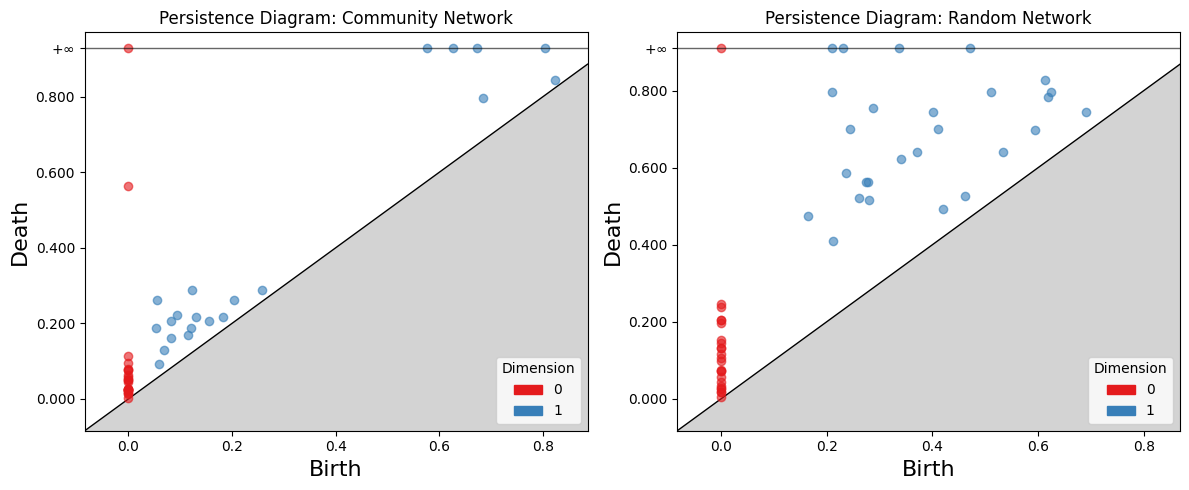

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gd.plot_persistence_diagram(persistence_community, axes=axes[0])
axes[0].set_title("Persistence Diagram: Community Network")

gd.plot_persistence_diagram(persistence_random, axes=axes[1])
axes[1].set_title("Persistence Diagram: Random Network")

plt.tight_layout()
plt.show()

## 9. Persistence barcodes

Barcodes show the same information as intervals. Long intervals suggest more persistent topological structure.

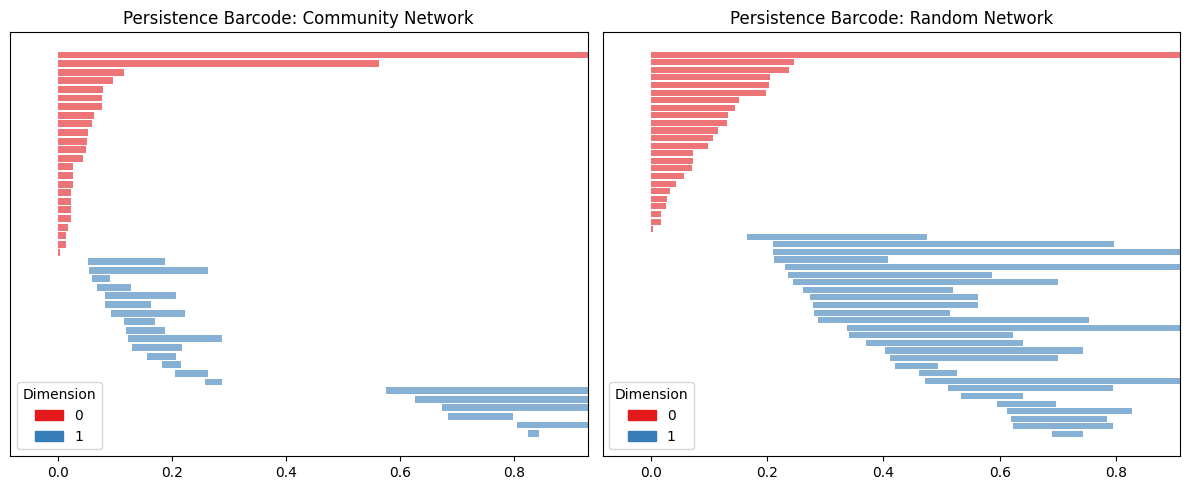

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gd.plot_persistence_barcode(persistence_community, axes=axes[0])
axes[0].set_title("Persistence Barcode: Community Network")

gd.plot_persistence_barcode(persistence_random, axes=axes[1])
axes[1].set_title("Persistence Barcode: Random Network")

plt.tight_layout()
plt.show()

## 10. Extract persistence intervals by dimension

We will extract finite intervals for H0 and H1.

GUDHI also includes one infinite H0 class for the final connected component, if the complex becomes connected. For distance computations below, we will focus on finite intervals.

In [10]:
def intervals_by_dimension(simplex_tree, dimension, finite_only=True):
    intervals = simplex_tree.persistence_intervals_in_dimension(dimension)

    if finite_only:
        intervals = np.array([interval for interval in intervals if np.isfinite(interval[1])])

    if len(intervals) == 0:
        return np.empty((0, 2))

    return np.asarray(intervals, dtype=float)


community_h0 = intervals_by_dimension(ST_community, 0)
community_h1 = intervals_by_dimension(ST_community, 1)

random_h0 = intervals_by_dimension(ST_random, 0)
random_h1 = intervals_by_dimension(ST_random, 1)

print("Community H0 intervals:", community_h0.shape)
print("Community H1 intervals:", community_h1.shape)
print("Random H0 intervals:", random_h0.shape)
print("Random H1 intervals:", random_h1.shape)

Community H0 intervals: (23, 2)
Community H1 intervals: (17, 2)
Random H0 intervals: (23, 2)
Random H1 intervals: (23, 2)


## 11. Compare lifetime distributions

The lifetime of a feature is:

$$\text{lifetime} = \text{death} - \text{birth}$$

This provides a simple summary of how persistent the topological features are.

In [11]:
def lifetimes(intervals):
    if len(intervals) == 0:
        return np.array([])
    return intervals[:, 1] - intervals[:, 0]


community_h0_lifetimes = lifetimes(community_h0)
community_h1_lifetimes = lifetimes(community_h1)
random_h0_lifetimes = lifetimes(random_h0)
random_h1_lifetimes = lifetimes(random_h1)

print("Community H0 largest lifetimes:", np.sort(community_h0_lifetimes)[-5:])
print("Random H0 largest lifetimes:", np.sort(random_h0_lifetimes)[-5:])
print("Community H1 largest lifetimes:", np.sort(community_h1_lifetimes)[-5:])
print("Random H1 largest lifetimes:", np.sort(random_h1_lifetimes)[-5:])

Community H0 largest lifetimes: [0.07735128 0.0789875  0.09599953 0.11471597 0.56243224]
Random H0 largest lifetimes: [0.19816972 0.2036827  0.2044297  0.23821383 0.24575068]
Community H1 largest lifetimes: [0.12476457 0.1297454  0.13459198 0.1647024  0.20796558]
Random H1 largest lifetimes: [0.3417262  0.34975557 0.45591561 0.4662033  0.58744527]


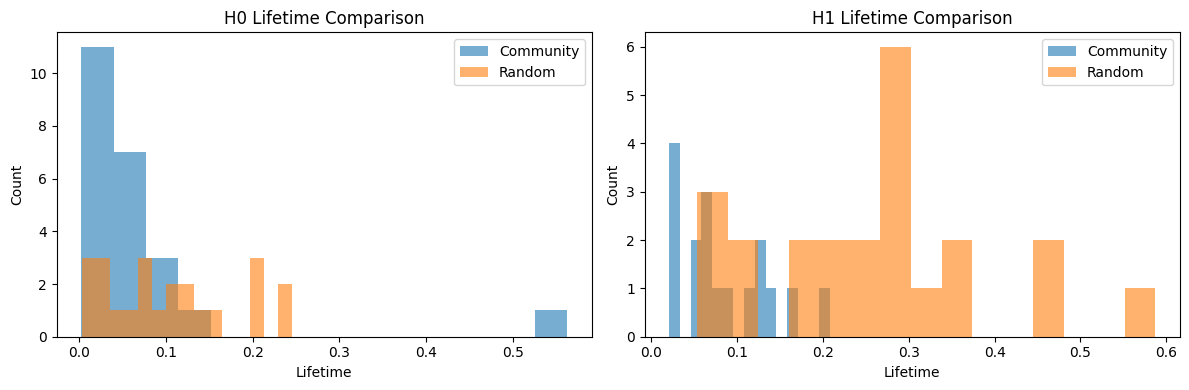

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(community_h0_lifetimes, bins=15, alpha=0.6, label="Community")
axes[0].hist(random_h0_lifetimes, bins=15, alpha=0.6, label="Random")
axes[0].set_title("H0 Lifetime Comparison")
axes[0].set_xlabel("Lifetime")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(community_h1_lifetimes, bins=15, alpha=0.6, label="Community")
axes[1].hist(random_h1_lifetimes, bins=15, alpha=0.6, label="Random")
axes[1].set_title("H1 Lifetime Comparison")
axes[1].set_xlabel("Lifetime")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

## 13. Visualize thresholded networks across scales

Because our filtration value is $1 - w$, a filtration threshold $t$ includes edges with:

$$1 - w \leq t$$

or equivalently:

$$w \geq 1 - t$$

So as $t$ grows, weaker edges are gradually added.

In [14]:
def threshold_graph_by_filtration(G, threshold):
    H = nx.Graph()
    H.add_nodes_from(G.nodes())

    for u, v, data in G.edges(data=True):
        filtration_value = 1.0 - data["weight"]
        if filtration_value <= threshold:
            H.add_edge(u, v, weight=data["weight"])

    return H


def plot_threshold_sequence(G, thresholds, pos, title_prefix):
    fig, axes = plt.subplots(1, len(thresholds), figsize=(4 * len(thresholds), 4))

    if len(thresholds) == 1:
        axes = [axes]

    for ax, t in zip(axes, thresholds):
        H = threshold_graph_by_filtration(G, t)
        plot_weighted_graph(H, ax, f"{title_prefix}\nt={t:.2f}", pos=pos)

    plt.tight_layout()
    plt.show()

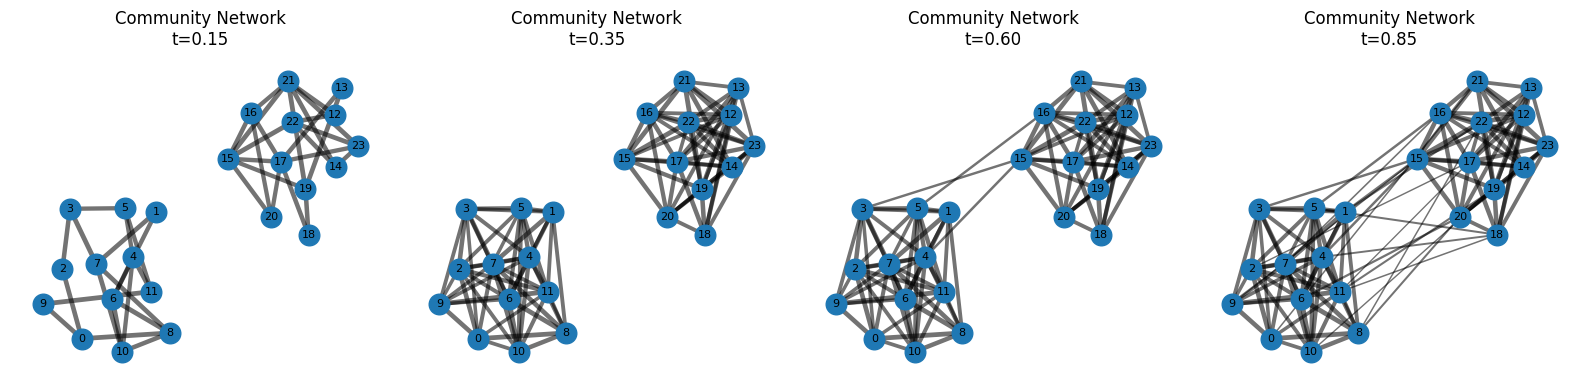

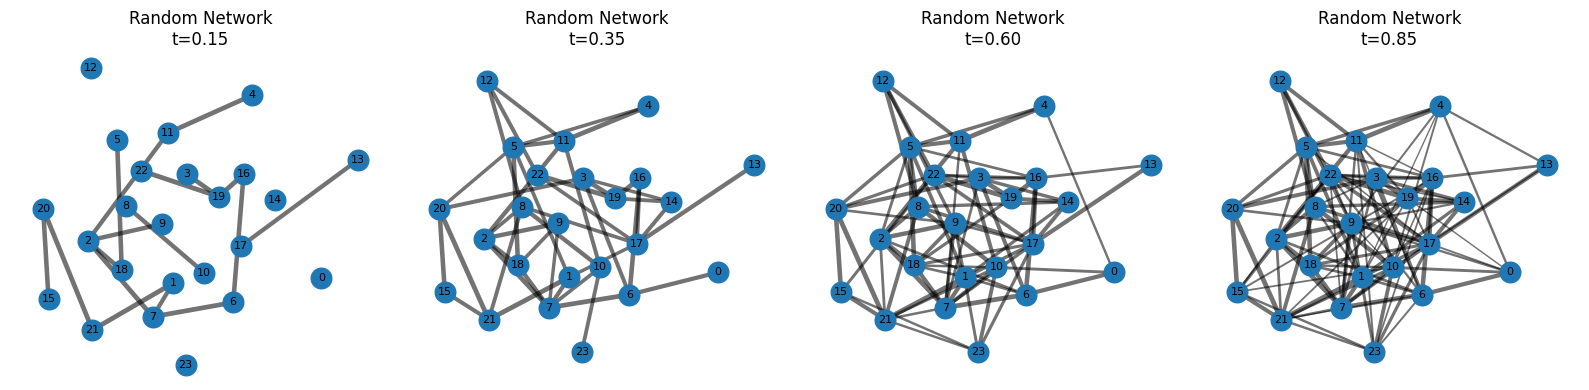

In [15]:
thresholds = [0.15, 0.35, 0.60, 0.85]

plot_threshold_sequence(G_community, thresholds, pos_community, "Community Network")
plot_threshold_sequence(G_random, thresholds, pos_random, "Random Network")

## 14. Discussion questions

1. Which network has a larger H0 bottleneck distance from the other? What does that say about component merging?
2. Which network has more H1 features? Are those features long-lived or short-lived?
3. How do the persistence diagrams change if the community network has more between-community edges?
4. How do the results change if edge weight means distance rather than similarity?
5. Which graph statistic agrees most closely with the persistence-based comparison?

## 15. Key takeaway

Persistent homology provides a multiscale way to compare networks. Instead of choosing one fixed threshold, we track how connectivity and loop-like structures evolve as edges enter the filtration.

In this tutorial, we:

1. Created two weighted networks.
2. Built filtered clique complexes using GUDHI's `SimplexTree`.
3. Computed persistent homology.
4. Compared diagrams visually and numerically using bottleneck distance.

The most important modeling step is the filtration. Always choose a filtration that matches the meaning of your network weights.